# Global Sports Footwear Sales Analysis
Created by Daniel Stromsodt

### Objective:
* To determine how pricing, category, brand, and country affect sales performance and revenue and how it could support data-driven business decisions.

In [9]:
# Import all used libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Data Overview:

In [10]:
# Read in data and examine data to understand the format
df = pd.read_csv("global_sports_footwear_sales_2018_2026_test.csv")
print(df.head())
print(df.info())
print(df.describe())

    order_id  order_date   brand model_name    category  gender  size  color  \
0  ORD100000   1/30/2021   ASICS  Model-370     Running  Unisex     8  Black   
1  ORD100001   10/5/2026  Reebok  Model-314   Lifestyle     Men     8   Grey   
2  ORD100002  11/12/2023   ASICS  Model-763   Lifestyle     Men     8  Black   
3  ORD100003   8/29/2026  Reebok  Model-905  Basketball   Women     7  White   
4  ORD100004   11/9/2019    Nike  Model-413    Training     Men    11  Black   

   base_price_usd  discount_percent  final_price_usd  units_sold  revenue_usd  \
0             162                15           137.70           1        137.7   
1              80                 5            76.00           3        228.0   
2             176                15           149.60           4        598.4   
3              61                15            51.85           2        103.7   
4              80                 0            80.00           4        320.0   

  payment_method sales_channel  

## Exploratory Analysis:

In [11]:
# Understand correlation between base price and units sold per item
corr, p_value = pearsonr(df["base_price_usd"], df["units_sold"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.005352756033227363
P-value: 0.3538784834162342


A p-value over 0.05 indicates that the base price is not a statistically significant predictor of units sold.

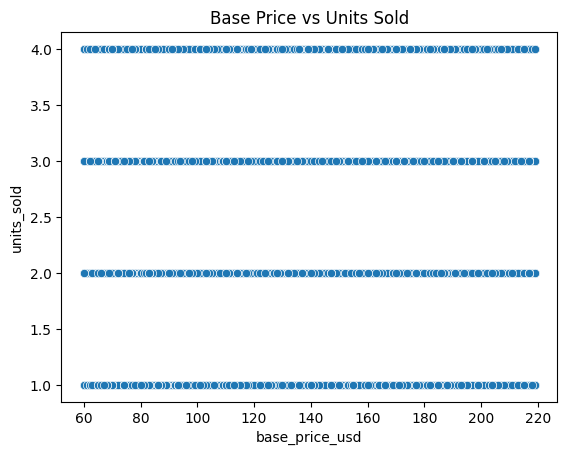

In [12]:
# Visualize findings to confirm lack of relationship between the base price and units sold
sns.scatterplot(x="base_price_usd", y="units_sold", data=df)
plt.title("Base Price vs Units Sold")
plt.show()

In [23]:
# Output OLS results for the
import statsmodels.api as sm

X = df["base_price_usd"]
y = df["units_sold"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8595
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.354
Time:                        17:28:55   Log-Likelihood:                -45998.
No. Observations:               30000   AIC:                         9.200e+04
Df Residuals:                   29998   BIC:                         9.202e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.4820      0.021    120.

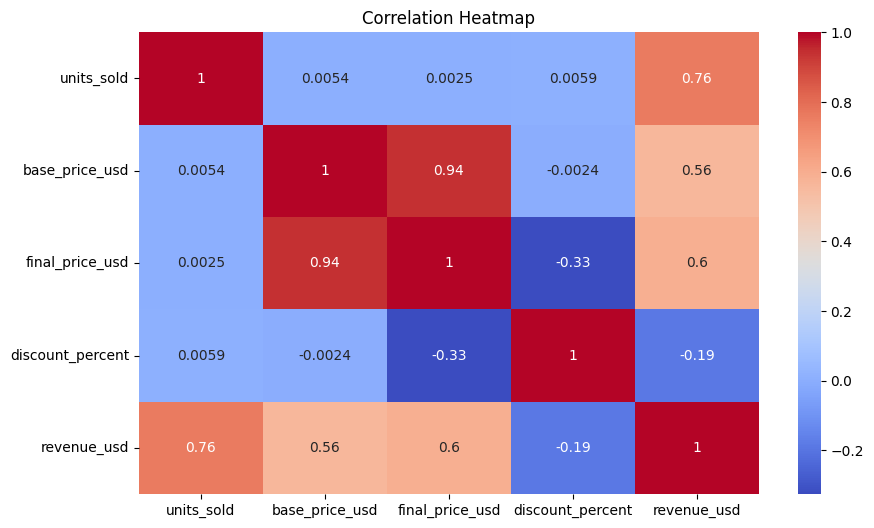

In [ ]:
# Take all numeric variables to understand which variables do have correlation with revenue
plt.figure(figsize=(10,6))
sns.heatmap(df[['units_sold','base_price_usd','final_price_usd','discount_percent','revenue_usd']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

It appears that there indeed isn't a strong correlation between the base price and the units sold, so we'll need to do some more digging into other variables

## Multiple Linear Regression Model:

In [13]:
# Section out multiple variables to create a multiple linear regression model
X = df[['units_sold','base_price_usd','final_price_usd','discount_percent','category','country','brand']]
y = df['revenue_usd']

# Identify categorical features
categorical_features = ['category', 'country', 'brand']
numeric_features = ['units_sold','base_price_usd','final_price_usd','discount_percent']

In [14]:
# Preprocessing for categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),('num', 'passthrough', numeric_features)])

In [15]:
# Intitiate pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

## Model Evaluation:

In [16]:
# Fit model using train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Output R² score (Pearson's correlation coefficient)
print("R²:", r2_score(y_test, y_pred))

R²: 0.9297137903434647


In [17]:
# Account for the number of variables present with the Adjusted R² value to confirm accuracy
n = len(y_test)
p = X_test.shape[1]

r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.9296316802854547


In [18]:
# View model metrics Root Mean Square Error (RMSE) and Mean Absolute Error (MAE) to evaluate model accuracy
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 47.19111157857223
MAE: 35.83084812255539


## Coefficients:

In [19]:
# Process features to prepare for the regression model
feature_names = (
    model.named_steps['preprocessor']
    .transformers_[0][1]
    .get_feature_names_out(categorical_features)
    .tolist()
    + numeric_features
)

In [20]:
# Get the trained preprocessor
preprocessor = model.named_steps['preprocessor']

# Get feature names after encoding
encoded_features = preprocessor.get_feature_names_out()

# Get coefficients
coefficients = model.named_steps['regressor'].coef_

In [21]:
# Output table to display variables and their coefficients that display how strong the relationship with revenue is
coef_df = pd.DataFrame({
    "Feature": encoded_features,
    "Coefficient": coefficients
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
14,num__units_sold,121.074022
16,num__final_price_usd,2.487476
4,cat__country_India,0.884710
12,cat__brand_Puma,0.707524
11,cat__brand_Nike,0.673432
5,cat__country_Pakistan,0.426419
15,num__base_price_usd,0.013065
17,num__discount_percent,-0.008862
8,cat__country_USA,-0.179924
7,cat__country_UK,-0.569436


## Key Findings:
* Units sold has the strongest postive impact on revenue
* Final price was another strong predictor for revenue
* Base price alone does not significany impact units sold (p-value > 0.05)
* Categorical variables like brand, category, and country have smaller but also relevant affects on revenue

These findings support the fact that reveenue is driven most by sales volume and effecctive pricing than through base price alone.